In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [2]:
ticker = "NVDA"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True
)

df = df[["Close"]]

print(df.head())
print(df.tail())
print(df.shape)

[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          NVDA
Date                
2018-01-02  4.922530
2018-01-03  5.246501
2018-01-04  5.274155
2018-01-05  5.318851
2018-01-08  5.481823
Price            Close
Ticker            NVDA
Date                  
2024-12-24  140.010910
2024-12-26  139.721329
2024-12-27  136.805664
2024-12-30  137.284958
2024-12-31  134.089737
(1761, 1)


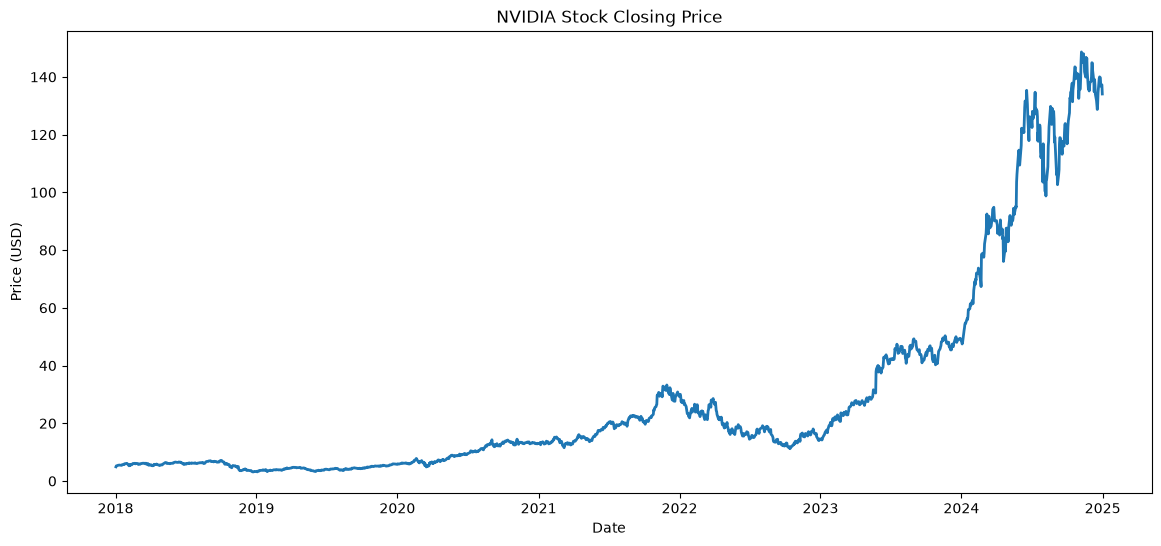

In [3]:
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], linewidth=2)

plt.title("NVIDIA Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.show()

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(df.values)

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1731, 30, 1)
(1731, 1)


In [5]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

torch.Size([1384, 30, 1])
torch.Size([1384, 1])
torch.Size([347, 30, 1])
torch.Size([347, 1])


In [6]:
class LSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=device
        )

        c0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size,
            device=device
        )

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out

In [9]:
model = LSTMModel(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    output_size=1
).to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [11]:
epochs = 200

for epoch in range(epochs):

    model.train()

    predictions = model(X_train)

    loss = criterion(predictions, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}]  Loss: {loss.item():.6f}")

Epoch [20/200]  Loss: 0.000076
Epoch [40/200]  Loss: 0.000074
Epoch [60/200]  Loss: 0.000073
Epoch [80/200]  Loss: 0.000071
Epoch [100/200]  Loss: 0.000070
Epoch [120/200]  Loss: 0.000068
Epoch [140/200]  Loss: 0.000066
Epoch [160/200]  Loss: 0.000065
Epoch [180/200]  Loss: 0.000063
Epoch [200/200]  Loss: 0.000062


In [12]:
model.eval()

with torch.no_grad():
    train_predictions = model(X_train)
    test_predictions = model(X_test)

train_predictions = train_predictions.cpu().numpy()
test_predictions = test_predictions.cpu().numpy()

y_train_actual = y_train.cpu().numpy()
y_test_actual = y_test.cpu().numpy()

In [13]:
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

y_train_actual = scaler.inverse_transform(y_train_actual)
y_test_actual = scaler.inverse_transform(y_test_actual)

In [14]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))

print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse:.2f}")

Training RMSE: 1.15
Testing RMSE: 9.44


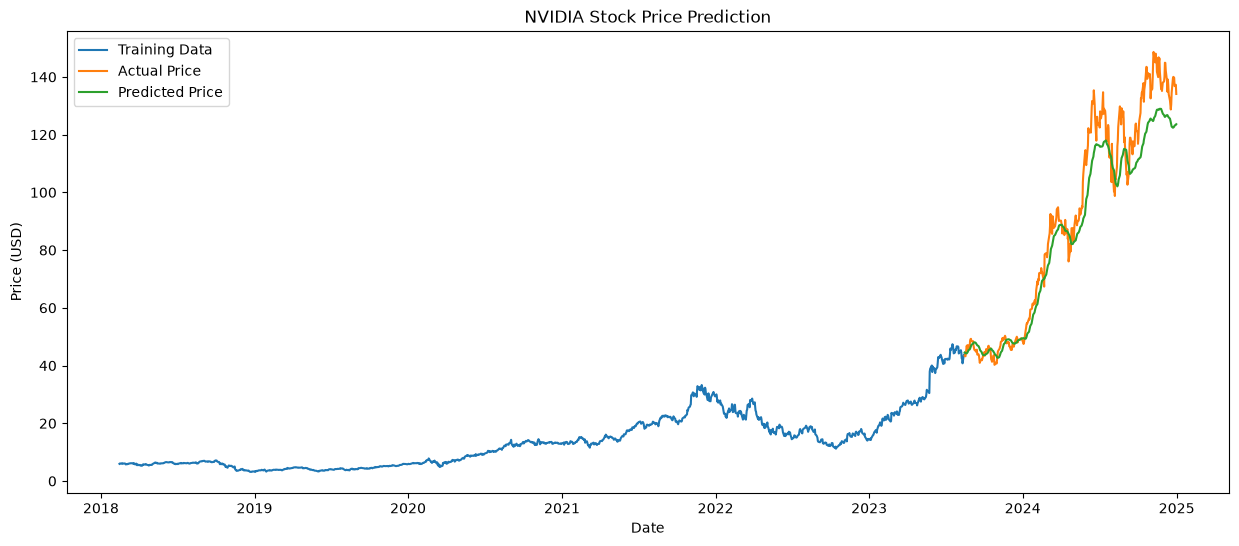

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(df.index[sequence_length:train_size + sequence_length],
         y_train_actual,
         label="Training Data")

plt.plot(df.index[train_size + sequence_length:],
         y_test_actual,
         label="Actual Price")

plt.plot(df.index[train_size + sequence_length:],
         test_predictions,
         label="Predicted Price")

plt.title("NVIDIA Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.show()

In [17]:
last_sequence = scaled_data[-sequence_length:]

last_sequence = torch.tensor(
    last_sequence,
    dtype=torch.float32
).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    next_day_prediction = model(last_sequence)

next_day_prediction = next_day_prediction.cpu().numpy()
next_day_prediction = scaler.inverse_transform(next_day_prediction)

latest_close = float(df["Close"].iloc[-1].item())

predicted_close = next_day_prediction[0][0]

change = predicted_close - latest_close
percent_change = (change / latest_close) * 100

print(f"Latest Closing Price      : ${latest_close:.2f}")
print(f"Predicted Closing Price   : ${predicted_close:.2f}")
print(f"Expected Change           : ${change:.2f} ({percent_change:.2f}%)")

Latest Closing Price      : $134.09
Predicted Closing Price   : $123.61
Expected Change           : $-10.48 (-7.82%)


In [18]:
torch.save(model.state_dict(), "nvda_lstm_model.pth")

print("Model saved successfully!")

Model saved successfully!
